# Phase 5: Feature Extraction - LPDP Sentiment Analysis

## Tujuan
Mengekstrak features dari teks yang sudah dipreproses menggunakan 3 metode:
1. **TF-IDF Vectorization (n-gram)** - Traditional feature extraction
2. **Bag of Words (BoW) Baseline** - Simple baseline approach
3. **IndoBERT Embeddings ([CLS] token)** - Deep learning contextual embeddings

## Output
- `feature_tfidf_ngram.pkl` - TF-IDF matrix dengan n-gram (1,2,3)
- `feature_bow.pkl` - Bag of Words matrix
- `feature_indobert_embeddings.pkl` - IndoBERT embeddings (768-dim)
- `feature_extraction_summary.json` - Metadata dan statistik

## Dataset
- Input: `dataset_lpdp_preprocessed.csv` (1.038 artikel dengan `text_clean`)
- Target: Sentimen labels (Positive/Negative/Neutral)

## Setup: Import Libraries dan Load Dataset

In [9]:
! pip install scikit-learn

In [1]:
# Data manipulation
import pandas as pd
import numpy as np
import pickle
import json
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Traditional NLP: TF-IDF & BoW
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import normalize

# Deep Learning: IndoBERT
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm

# Visualization & Utilities
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("✅ All libraries imported successfully")
print(f"PyTorch device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

✅ All libraries imported successfully
PyTorch device: cpu


In [2]:
# Set working directory
work_dir = Path.cwd()
print(f"Working directory: {work_dir}")

# Load preprocessed dataset
df = pd.read_csv('dataset_lpdp_preprocessed.csv')

print(f"\n📊 Dataset Loaded:")
print(f"  - Total articles: {len(df)}")
print(f"  - Columns: {df.columns.tolist()}")
print(f"\n  Sentiment distribution:")
print(df['Sentiment'].value_counts())

# Check for missing values in text_clean
missing_count = df['text_clean'].isna().sum()
empty_count = (df['text_clean'].str.len() == 0).sum()
print(f"\n  Missing values: {missing_count}")
print(f"  Empty strings: {empty_count}")

# Show sample
print(f"\n📝 Sample text_clean (first article):")
print(df['text_clean'].iloc[0][:200] + "...")

Working directory: c:\Users\Salwa\OneDrive\Dokumen\PBA\PBA\Project A

📊 Dataset Loaded:
  - Total articles: 1038
  - Columns: ['doc_id', 'Title', 'Release Date', 'URL', 'Publisher', 'PiC', 'Valid?', 'Sentiment', 'Notes', 'Actual_URL', 'Content', 'label_4', 'label_name', 'text_clean']

  Sentiment distribution:
Sentiment
Positive    385
Neutral     342
Negative    311
Name: count, dtype: int64

  Missing values: 0
  Empty strings: 0

📝 Sample text_clean (first article):
cegah kolusi nepotisme program lpdp nilai ketat seleksi jakarta sekretaris komisi e dprd dki jakarta justin adrian untayana nilai seleksi terima program beasiswa lembaga kelola dana didik lpdp versi j...


## Method 1: TF-IDF Vectorization (n-gram)

TF-IDF (Term Frequency-Inverse Document Frequency) adalah metode klasik untuk mengekstrak features dari teks.

**Konfigurasi:**
- **n-gram:** (1,2,3) - unigram, bigram, trigram
- **min_df:** 2 - minimum document frequency (hapus term yang muncul di < 2 dokumen)
- **max_df:** 0.95 - maximum document frequency (hapus term yang muncul di > 95% dokumen)
- **max_features:** 5000 - ambil top 5000 features terbaik

**Output:** Sparse matrix (1.038 x 5000)

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Pastikan kolom teks tidak ada NaN
texts = df['text_clean'].fillna('').astype(str)

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),          # unigram, bigram, trigram
    min_df=2,                    # minimal muncul di 2 dokumen
    max_df=0.95,                 # buang term yang terlalu umum
    max_features=5000,           # batasi 5000 fitur
    strip_accents='unicode',
    lowercase=True,
    analyzer='word',
    token_pattern=r'\w{2,}',     # minimal 2 karakter, lebih bersih dari \w{1,}
    sublinear_tf=True
)

# Fit and transform
X_tfidf = tfidf_vectorizer.fit_transform(texts)

# Feature names
feature_names = tfidf_vectorizer.get_feature_names_out()

# Matrix stats
n_docs, n_features = X_tfidf.shape
total_elements = n_docs * n_features
non_zero = X_tfidf.nnz
density = non_zero / total_elements
sparsity = 1 - density

# TF-IDF value stats
tfidf_min = X_tfidf.data.min() if non_zero > 0 else 0
tfidf_max = X_tfidf.data.max() if non_zero > 0 else 0
tfidf_mean = X_tfidf.data.mean() if non_zero > 0 else 0

print("✅ TF-IDF extraction complete\n")
print(f"📊 TF-IDF Matrix Shape: {X_tfidf.shape}")
print(f"  - Documents: {n_docs}")
print(f"  - Features: {n_features}")
print(f"  - Non-zero values: {non_zero}")
print(f"  - Density: {density:.2%}")
print(f"  - Sparsity: {sparsity:.2%}")

print("\n  Sample features (first 20):")
print(feature_names[:20])

print("\n  TF-IDF value statistics:")
print(f"  - Min: {tfidf_min:.4f}")
print(f"  - Max: {tfidf_max:.4f}")
print(f"  - Mean: {tfidf_mean:.4f}")


✅ TF-IDF extraction complete

📊 TF-IDF Matrix Shape: (1038, 5000)
  - Documents: 1038
  - Features: 5000
  - Non-zero values: 218277
  - Density: 4.21%
  - Sparsity: 95.79%

  Sample features (first 20):
['aas' 'abadi' 'abadi bidang' 'abadi bidang didik' 'abadi budaya'
 'abadi didik' 'abadi didik kelola' 'abadi guru' 'abadi kelola'
 'abadi kelola lpdp' 'abadi lpdp' 'abadi teliti' 'abdi' 'abdi alumni'
 'abdi indonesia' 'abdi indonesia kali' 'abdi indonesia selesai'
 'abdi kali' 'abdi kontribusi' 'abdi kontribusi indonesia']

  TF-IDF value statistics:
  - Min: 0.0068
  - Max: 0.5916
  - Mean: 0.0610



📈 Top 20 TF-IDF Features (by average score):
   1. beasiswa             - 0.0431
   2. terima               - 0.0322
   3. indonesia            - 0.0304
   4. didik                - 0.0300
   5. beasiswa lpdp        - 0.0287
   6. dana                 - 0.0287
   7. program              - 0.0273
   8. terima beasiswa      - 0.0265
   9. negara               - 0.0261
  10. daftar               - 0.0257
  11. studi                - 0.0257
  12. s                    - 0.0251
  13. negeri               - 0.0243
  14. anak                 - 0.0234
  15. alumni               - 0.0216
  16. seleksi              - 0.0207
  17. kelola               - 0.0203
  18. orang                - 0.0202
  19. kontribusi           - 0.0201
  20. milik                - 0.0199


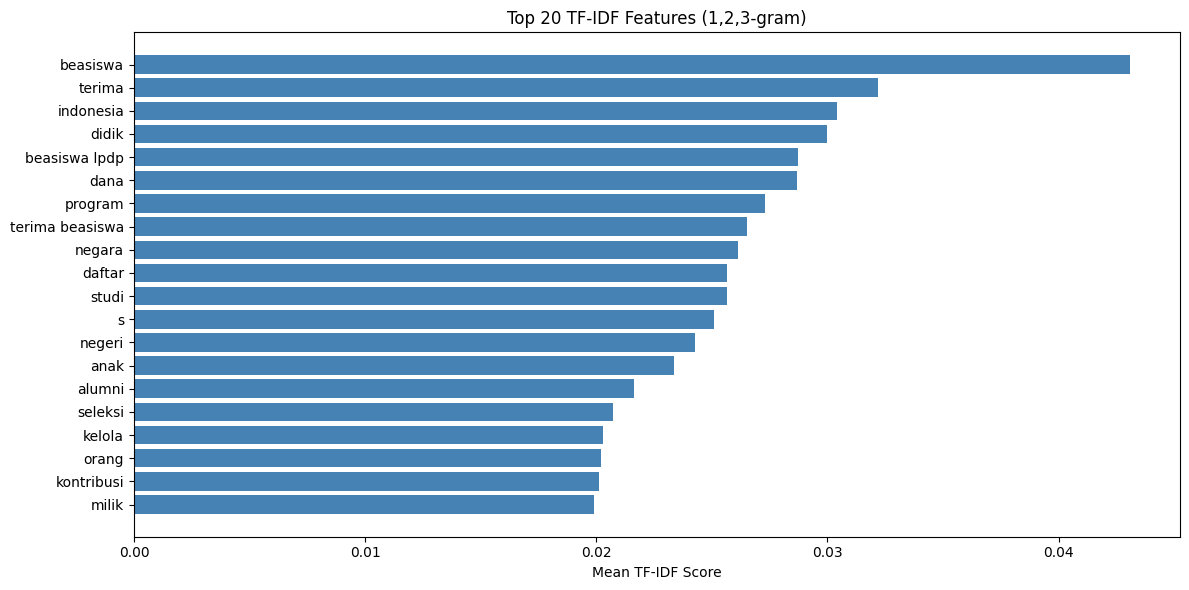

In [5]:
# Visualize top TF-IDF features
# Calculate mean TF-IDF score per feature
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()
top_indices = mean_tfidf.argsort()[-20:][::-1]
top_features = feature_names_tfidf[top_indices]
top_scores = mean_tfidf[top_indices]

print("\n📈 Top 20 TF-IDF Features (by average score):")
for i, (feature, score) in enumerate(zip(top_features, top_scores), 1):
    print(f"  {i:2d}. {feature:20s} - {score:.4f}")

# Plot
plt.figure(figsize=(12, 6))
plt.barh(range(len(top_features)), top_scores, color='steelblue')
plt.yticks(range(len(top_features)), top_features)
plt.xlabel('Mean TF-IDF Score')
plt.title('Top 20 TF-IDF Features (1,2,3-gram)')
plt.gca().invert_yaxis()  # fitur tertinggi tampil di atas
plt.tight_layout()
plt.show()

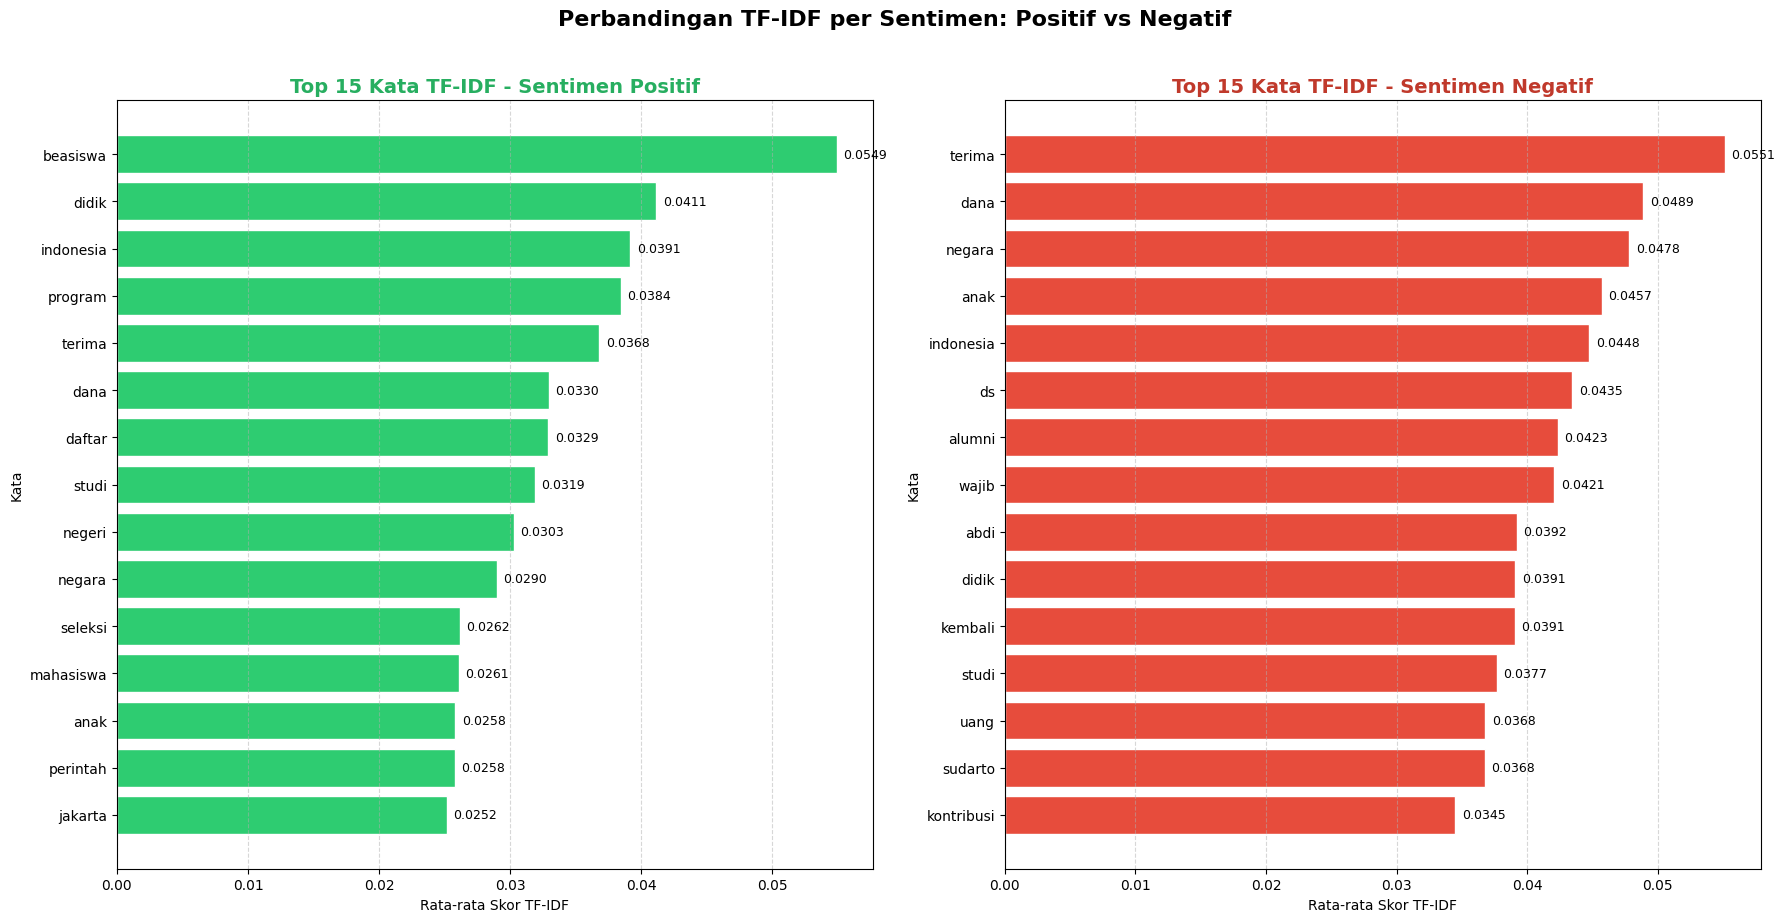

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# Ambil data per sentimen
df_pos = df[df['Sentiment'] == 'Positive'].copy()
df_neg = df[df['Sentiment'] == 'Negative'].copy()

text_pos = df_pos['text_clean'].fillna('').astype(str)
text_neg = df_neg['text_clean'].fillna('').astype(str)

# TF-IDF per sentimen
tfidf_vectorizer_pos = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.95,
    max_features=5000,
    lowercase=True,
    token_pattern=r'\w{2,}',
    sublinear_tf=True
)

tfidf_vectorizer_neg = TfidfVectorizer(
    ngram_range=(1, 1),
    min_df=2,
    max_df=0.95,
    max_features=5000,
    lowercase=True,
    token_pattern=r'\w{2,}',
    sublinear_tf=True
)

tfidf_matrix_pos = tfidf_vectorizer_pos.fit_transform(text_pos)
tfidf_matrix_neg = tfidf_vectorizer_neg.fit_transform(text_neg)

feature_names_pos = tfidf_vectorizer_pos.get_feature_names_out()
feature_names_neg = tfidf_vectorizer_neg.get_feature_names_out()

# Rata-rata skor TF-IDF per fitur
mean_tfidf_pos = np.asarray(tfidf_matrix_pos.mean(axis=0)).ravel()
mean_tfidf_neg = np.asarray(tfidf_matrix_neg.mean(axis=0)).ravel()

df_tfidf_pos = pd.DataFrame({
    'Kata': feature_names_pos,
    'Skor_TFIDF': mean_tfidf_pos
}).sort_values(by='Skor_TFIDF', ascending=False)

df_tfidf_neg = pd.DataFrame({
    'Kata': feature_names_neg,
    'Skor_TFIDF': mean_tfidf_neg
}).sort_values(by='Skor_TFIDF', ascending=False)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Plot Positif
top15_pos = df_tfidf_pos.head(15)
axes[0].barh(
    top15_pos['Kata'][::-1],
    top15_pos['Skor_TFIDF'][::-1],
    color='#2ecc71',
    edgecolor='white'
)
axes[0].set_title('Top 15 Kata TF-IDF - Sentimen Positif', fontsize=14, fontweight='bold', color='#27ae60')
axes[0].set_xlabel('Rata-rata Skor TF-IDF')
axes[0].set_ylabel('Kata')
axes[0].grid(axis='x', linestyle='--', alpha=0.5)

for i, (kata, skor) in enumerate(zip(top15_pos['Kata'][::-1], top15_pos['Skor_TFIDF'][::-1])):
    axes[0].text(skor + 0.0005, i, f'{skor:.4f}', va='center', fontsize=9)

# Plot Negatif
top15_neg = df_tfidf_neg.head(15)
axes[1].barh(
    top15_neg['Kata'][::-1],
    top15_neg['Skor_TFIDF'][::-1],
    color='#e74c3c',
    edgecolor='white'
)
axes[1].set_title('Top 15 Kata TF-IDF - Sentimen Negatif', fontsize=14, fontweight='bold', color='#c0392b')
axes[1].set_xlabel('Rata-rata Skor TF-IDF')
axes[1].set_ylabel('Kata')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)

for i, (kata, skor) in enumerate(zip(top15_neg['Kata'][::-1], top15_neg['Skor_TFIDF'][::-1])):
    axes[1].text(skor + 0.0005, i, f'{skor:.4f}', va='center', fontsize=9)

plt.suptitle('Perbandingan TF-IDF per Sentimen: Positif vs Negatif', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Method 2: Bag of Words (BoW) Baseline

Bag of Words adalah metode paling sederhana - hanya menghitung term frequency tanpa normalisasi TF-IDF.

**Konfigurasi:**
- **Analyzer:** word-level
- **min_df:** 2 - minimum document frequency
- **max_df:** 0.95 - maximum document frequency
- **max_features:** 5000 - top 5000 features

**Output:** Sparse matrix dengan word counts (1.038 x 5000)

In [29]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

texts = df['text_clean'].fillna('').astype(str)

bow_vectorizer = CountVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.90,
    max_features=5000,
    lowercase=True,
    token_pattern=r'\w{2,}'
)

X_bow = bow_vectorizer.fit_transform(texts)
feature_names_bow = bow_vectorizer.get_feature_names_out()

n_docs, n_features = X_bow.shape
total_elements = n_docs * n_features
non_zero = X_bow.nnz
density = non_zero / total_elements
sparsity = 1 - density

bow_min = X_bow.data.min() if non_zero > 0 else 0
bow_max = X_bow.data.max() if non_zero > 0 else 0
bow_mean = X_bow.data.mean() if non_zero > 0 else 0
bow_median = np.median(X_bow.data) if non_zero > 0 else 0

print("✅ Bag of Words extraction complete\n")
print(f"📊 BoW Matrix Shape: {X_bow.shape}")
print(f"  - Documents: {n_docs}")
print(f"  - Features: {n_features}")
print(f"  - Non-zero values: {non_zero}")
print(f"  - Density: {density:.2%}")
print(f"  - Sparsity: {sparsity:.2%}")

print("\n  Sample features (first 20):")
print(feature_names_bow[:20])

print("\n  Term frequency statistics:")
print(f"  - Min: {bow_min}")
print(f"  - Max: {bow_max}")
print(f"  - Mean: {bow_mean:.2f}")
print(f"  - Median: {bow_median:.2f}")

✅ Bag of Words extraction complete

📊 BoW Matrix Shape: (1038, 5000)
  - Documents: 1038
  - Features: 5000
  - Non-zero values: 199613
  - Density: 3.85%
  - Sparsity: 96.15%

  Sample features (first 20):
['aas' 'abadi' 'abadi bidang' 'abadi budaya' 'abadi didik' 'abadi guru'
 'abadi kelola' 'abadi lpdp' 'abadi teliti' 'abai' 'abdi' 'abdi alumni'
 'abdi awardee' 'abdi indonesia' 'abdi kali' 'abdi kontribusi' 'abdi lpdp'
 'abdi maju' 'abdi masyarakat' 'abdi negara']

  Term frequency statistics:
  - Min: 1
  - Max: 63
  - Mean: 1.62
  - Median: 1.00



📈 Top 20 Terms (by total frequency):
   1. bawa nama            -   7945 occurrences
   2. daftar daftar        -   3584 occurrences
   3. tenaga didik         -   3548 occurrences
   4. dapat lpdp           -   3415 occurrences
   5. instansi             -   3254 occurrences
   6. cuat                 -   3032 occurrences
   7. potensi              -   2765 occurrences
   8. studi belanda        -   2288 occurrences
   9. msc                  -   2250 occurrences
  10. rupiah keluar        -   1990 occurrences
  11. muat                 -   1867 occurrences
  12. ana                  -   1736 occurrences
  13. sekian               -   1610 occurrences
  14. alumni terima        -   1376 occurrences
  15. ketua                -   1369 occurrences
  16. utrecht university   -   1334 occurrences
  17. masuk daftar         -   1324 occurrences
  18. beasiswa targeted    -   1253 occurrences
  19. nila triliun         -   1224 occurrences
  20. lpdp cakup           -   1208 occurrences


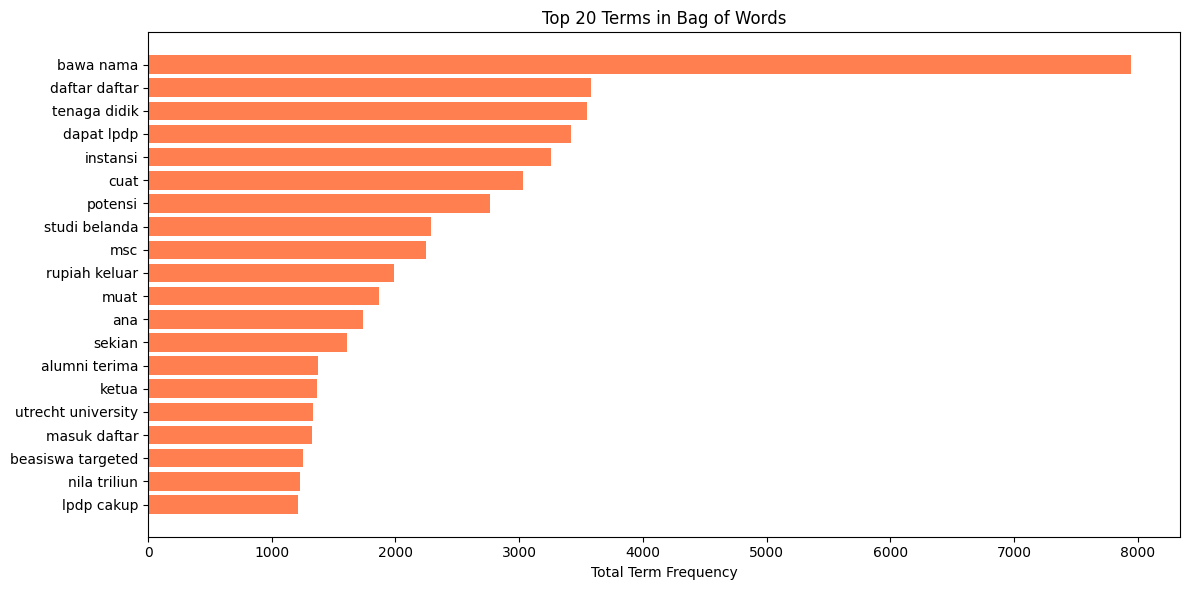

In [ ]:
# Visualize top BoW features
# Calculate total term frequency per feature
total_counts = np.asarray(bow_matrix.sum(axis=0)).ravel()
top_indices_bow = total_counts.argsort()[-20:][::-1]
top_features_bow = feature_names_bow[top_indices_bow]
top_counts = total_counts[top_indices_bow]

print("\n📈 Top 20 Terms (by total frequency):")
for i, (feature, count) in enumerate(zip(top_features_bow, top_counts), 1):
    print(f"  {i:2d}. {feature:20s} - {int(count):6d} occurrences")

# Plot
plt.figure(figsize=(12, 6))
plt.barh(range(len(top_features_bow)), top_counts, color='coral')
plt.yticks(range(len(top_features_bow)), top_features_bow)
plt.xlabel('Total Term Frequency')
plt.title('Top 20 Terms in Bag of Words')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

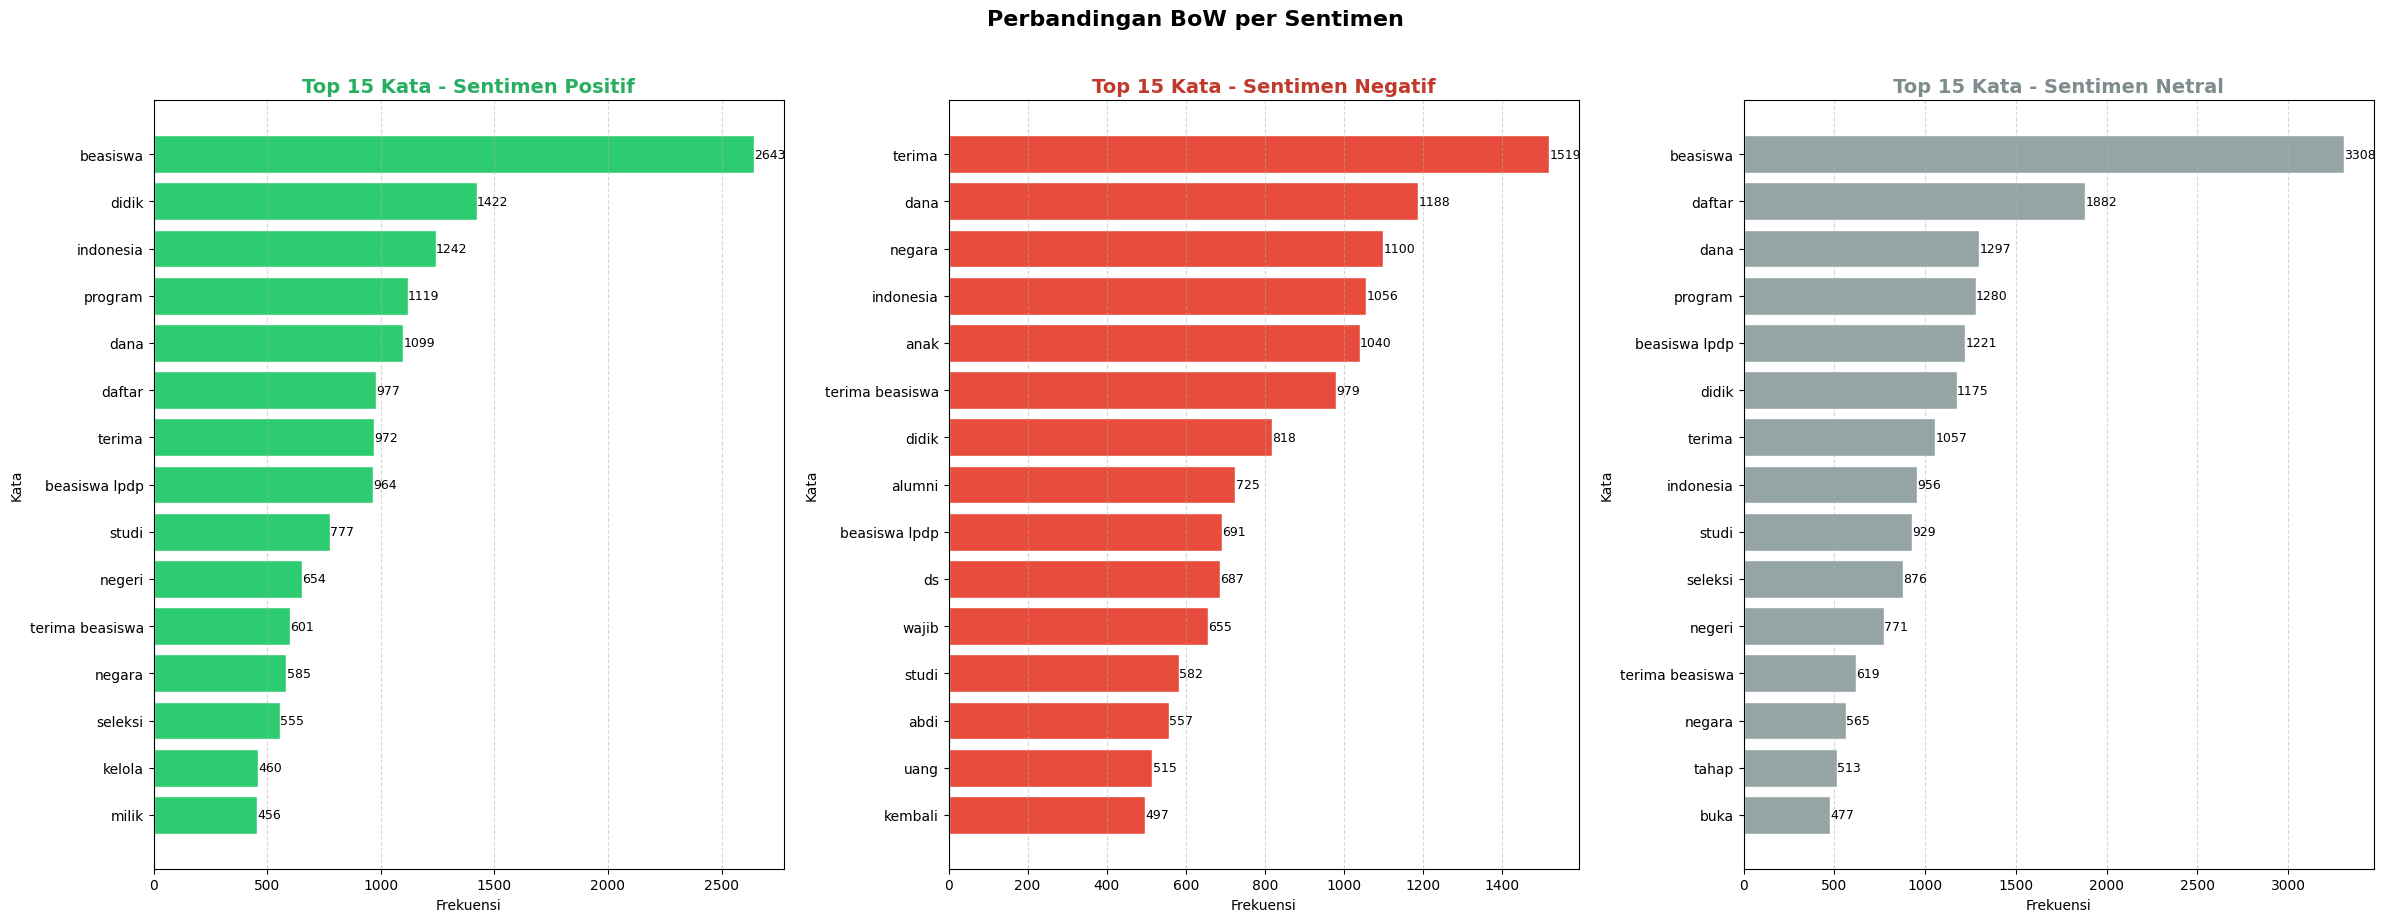

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

def get_top_words_by_sentiment(df, sentiment_label, top_n=15):
    texts = df[df['Sentiment'] == sentiment_label]['text_clean'].fillna('').astype(str)
    
    vectorizer = CountVectorizer(
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        token_pattern=r'\w{2,}'
    )
    
    X = vectorizer.fit_transform(texts)
    features = vectorizer.get_feature_names_out()
    counts = X.sum(axis=0).A1
    
    result = pd.DataFrame({
        'Kata': features,
        'Frekuensi': counts
    }).sort_values(by='Frekuensi', ascending=False).head(top_n)
    
    return result

df_bow_pos = get_top_words_by_sentiment(df, 'Positive', top_n=15)
df_bow_neg = get_top_words_by_sentiment(df, 'Negative', top_n=15)
df_bow_neu = get_top_words_by_sentiment(df, 'Neutral', top_n=15)

fig, axes = plt.subplots(1, 3, figsize=(24, 9))

plot_configs = [
    (df_bow_pos, 'Sentimen Positif', '#2ecc71', '#27ae60'),
    (df_bow_neg, 'Sentimen Negatif', '#e74c3c', '#c0392b'),
    (df_bow_neu, 'Sentimen Netral', '#95a5a6', '#7f8c8d')
]

for ax, (df_plot, title, bar_color, title_color) in zip(axes, plot_configs):
    ax.barh(
        df_plot['Kata'][::-1],
        df_plot['Frekuensi'][::-1],
        color=bar_color,
        edgecolor='white'
    )
    ax.set_title(f'Top 15 Kata - {title}', fontsize=14, fontweight='bold', color=title_color)
    ax.set_xlabel('Frekuensi')
    ax.set_ylabel('Kata')
    ax.grid(axis='x', linestyle='--', alpha=0.5)

    for i, (kata, freq) in enumerate(zip(df_plot['Kata'][::-1], df_plot['Frekuensi'][::-1])):
        ax.text(freq + 1, i, str(int(freq)), va='center', fontsize=9)

plt.suptitle('Perbandingan BoW per Sentimen', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Method 3: IndoBERT Embeddings ([CLS] Token)

IndoBERT adalah model transformer multilingual yang dilatih khusus untuk bahasa Indonesia.
Kami menggunakan **[CLS] token** dari output layer terakhir sebagai representasi dense dari keseluruhan dokumen.

**Model:** `indolem/indobert-base-uncased` (12 layers, 768 hidden dimension)

**Process:**
1. Tokenize setiap teks dengan IndoBERT tokenizer
2. Jalankan forward pass melalui model
3. Ekstrak [CLS] token embedding (768-dim)
4. Lakukan normalisasi L2

**Output:** Dense matrix (1.038 x 768)

In [22]:
print("🔄 Setting up IndoBERT Model...")
print("="*60)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Model and tokenizer
model_name = "indolem/indobert-base-uncased"
print(f"Loading model: {model_name}")

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model = model.to(device)
model.eval()  # Set to evaluation mode

print(f"✅ Model loaded successfully")
print(f"  - Model type: {type(model).__name__}")
print(f"  - Hidden size: {model.config.hidden_size}")
print(f"  - Num layers: {model.config.num_hidden_layers}")
print(f"  - Vocab size: {model.config.vocab_size}")

🔄 Setting up IndoBERT Model...
Using device: cpu
Loading model: indolem/indobert-base-uncased


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Error while downloading from https://huggingface.co/indolem/indobert-base-uncased/resolve/main/pytorch_model.bin: HTTPSConnectionPool(host='cas-bridge.xethub.hf.co', port=443): Read timed out.
Trying to resume download...
Error while downloading from https://huggingface.co/indolem/indobert-base-uncased/resolve/main/pytorch_model.bin: HTTPSConnectionPool(host='cas-bridge.xethub.hf.co', port=443): Read timed out.
Trying to resume download...
Error while downloading from https://huggingface.co/indolem/indobert-base-uncased/resolve/main/pytorch_model.bin: HTTPSConnectionPool(host='cas-bridge.xethub.hf.co', port=443): Read timed out.
Trying to resume download...


✅ Model loaded successfully
  - Model type: BertModel
  - Hidden size: 768
  - Num layers: 12
  - Vocab size: 31923


In [23]:
print("\n🔄 Extracting IndoBERT Embeddings...")
print("="*60)

# Parameters
batch_size = 32
max_length = 512
embeddings_list = []

# Process in batches
total_batches = (len(df) + batch_size - 1) // batch_size

with torch.no_grad():
    for batch_num in tqdm(range(total_batches), desc="Processing batches"):
        # Get batch texts
        start_idx = batch_num * batch_size
        end_idx = min((batch_num + 1) * batch_size, len(df))
        batch_texts = df['text_clean'].iloc[start_idx:end_idx].tolist()
        
        # Tokenize
        encoded = tokenizer(
            batch_texts,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        # Move to device
        input_ids = encoded['input_ids'].to(device)
        attention_mask = encoded['attention_mask'].to(device)
        
        # Forward pass
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )
        
        # Extract [CLS] token (first token of last hidden state)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings_list.append(cls_embeddings)

# Concatenate all batches
indobert_embeddings = np.vstack(embeddings_list)

print(f"✅ IndoBERT extraction complete")
print(f"\n📊 Embeddings Shape: {indobert_embeddings.shape}")
print(f"  - Documents: {indobert_embeddings.shape[0]}")
print(f"  - Dimensions: {indobert_embeddings.shape[1]}")
print(f"  - Data type: {indobert_embeddings.dtype}")


🔄 Extracting IndoBERT Embeddings...


Processing batches: 100%|██████████| 33/33 [17:06<00:00, 31.11s/it]   

✅ IndoBERT extraction complete

📊 Embeddings Shape: (1038, 768)
  - Documents: 1038
  - Dimensions: 768
  - Data type: float32


Artinya ada matrix berukuran 1038 baris dan 768 kolom.
1038 = jumlah dokumen
768 = jumlah fitur/angka untuk mewakili setiap dokumen

In [24]:
# Normalize embeddings (L2 normalization)
indobert_embeddings_normalized = normalize(indobert_embeddings, norm='l2')

print("\n🔧 Normalizing embeddings (L2 norm)...")
print(f"  - Before normalization:")
print(f"    Min: {indobert_embeddings.min():.4f}, Max: {indobert_embeddings.max():.4f}")
print(f"    Mean: {indobert_embeddings.mean():.4f}, Std: {indobert_embeddings.std():.4f}")

print(f"\n  - After L2 normalization:")
print(f"    Min: {indobert_embeddings_normalized.min():.4f}, Max: {indobert_embeddings_normalized.max():.4f}")
print(f"    Mean: {indobert_embeddings_normalized.mean():.4f}, Std: {indobert_embeddings_normalized.std():.4f}")

# Verify L2 norm (should be ~1.0 for all embeddings)
norms = np.linalg.norm(indobert_embeddings_normalized, axis=1)
print(f"\n  - L2 norms: Min={norms.min():.4f}, Max={norms.max():.4f}, Mean={norms.mean():.4f}")

# Use normalized embeddings
indobert_embeddings = indobert_embeddings_normalized


🔧 Normalizing embeddings (L2 norm)...
  - Before normalization:
    Min: -12.5836, Max: 4.7433
    Mean: 0.0259, Std: 0.9117

  - After L2 normalization:
    Min: -0.5054, Max: 0.1905
    Mean: 0.0010, Std: 0.0361

  - L2 norms: Min=1.0000, Max=1.0000, Mean=1.0000


Setelah normalisasi, semua nilai jadi lebih kecil karena vektornya diskalakan agar panjang totalnya = 1.

Min: -0.5054, Max: 0.1905
Mean: 0.0010, Std: 0.0361


🔄 Reducing dimensions for visualization (PCA)...
  - Explained variance ratio: 0.2215
  - PC1: 0.1374
  - PC2: 0.0841


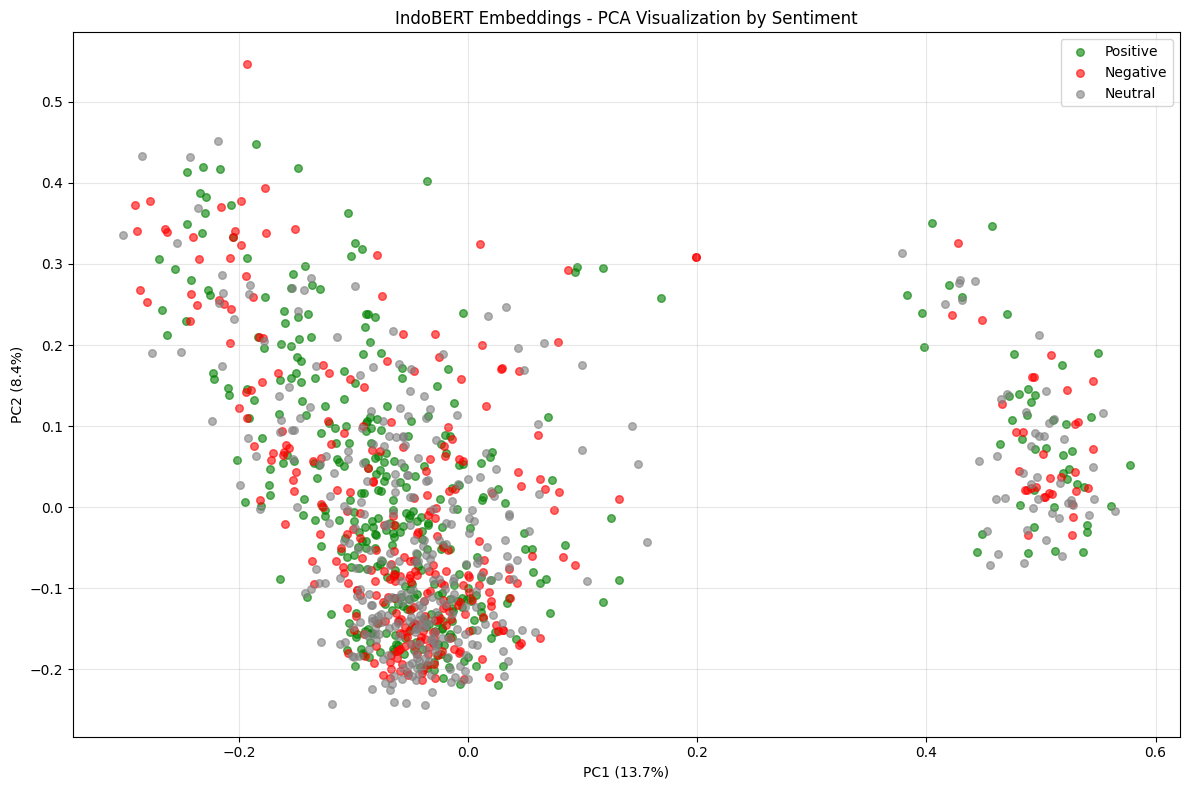

In [25]:
# Visualize embedding statistics
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

print("\n🔄 Reducing dimensions for visualization (PCA)...")

# PCA to 2D
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(indobert_embeddings)

print(f"  - Explained variance ratio: {pca.explained_variance_ratio_.sum():.4f}")
print(f"  - PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"  - PC2: {pca.explained_variance_ratio_[1]:.4f}")

# Plot with sentiment colors
sentiment_colors = {'Positive': 'green', 'Negative': 'red', 'Neutral': 'gray'}
colors = [sentiment_colors[s] for s in df['Sentiment']]

plt.figure(figsize=(12, 8))
for sentiment in ['Positive', 'Negative', 'Neutral']:
    mask = df['Sentiment'] == sentiment
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=sentiment,
        alpha=0.6,
        s=30,
        color=sentiment_colors[sentiment]
    )

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('IndoBERT Embeddings - PCA Visualization by Sentiment')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Hasil PCA menunjukkan bahwa dua komponen utama pertama menjelaskan 22.15% variasi total data, dengan kontribusi PC1 sebesar 13.74% dan PC2 sebesar 8.41%. Ini menunjukkan bahwa visualisasi 2D hanya merepresentasikan sebagian informasi dari embedding IndoBERT berdimensi tinggi.

## Comparison of Feature Extraction Methods

In [26]:
# Create comparison summary
comparison_df = pd.DataFrame({
    'Method': ['TF-IDF (n-gram)', 'Bag of Words', 'IndoBERT'],
    'Feature Type': ['Sparse (n-gram)', 'Sparse (terms)', 'Dense (embeddings)'],
    'Dimensionality': [tfidf_matrix.shape[1], bow_matrix.shape[1], indobert_embeddings.shape[1]],
    'Data Type': ['Sparse Matrix', 'Sparse Matrix', 'Dense Array'],
    'Memory (approx)': [
        f"{(tfidf_matrix.data.nbytes / 1024**2):.2f} MB",
        f"{(bow_matrix.data.nbytes / 1024**2):.2f} MB",
        f"{(indobert_embeddings.nbytes / 1024**2):.2f} MB"
    ],
    'Sparsity': [
        f"{(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1]))*100:.1f}%",
        f"{(1 - bow_matrix.nnz / (bow_matrix.shape[0] * bow_matrix.shape[1]))*100:.1f}%",
        "0% (Dense)"
    ],
    'Contextual': ['No', 'No', 'Yes (transformer)'],
    'Interpretability': ['High', 'High', 'Low']
})

print("\n📊 Feature Extraction Methods Comparison")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)


📊 Feature Extraction Methods Comparison
         Method       Feature Type  Dimensionality     Data Type Memory (approx)   Sparsity        Contextual Interpretability
TF-IDF (n-gram)    Sparse (n-gram)            5000 Sparse Matrix         1.68 MB      95.8%                No             High
   Bag of Words     Sparse (terms)            5000 Sparse Matrix         1.06 MB      97.3%                No             High
       IndoBERT Dense (embeddings)             768   Dense Array         3.04 MB 0% (Dense) Yes (transformer)              Low


TF-IDF
Seimbang untuk klasifikasi teks.
Masih mudah dijelaskan, dan lebih pintar dari BoW karena memberi bobot pentingnya kata.

BoW
Paling sederhana dan hemat memori.
Tapi hanya menghitung frekuensi kata, jadi biasanya kurang kuat dibanding TF-IDF.

IndoBERT
Paling kaya konteks.
Bisa menangkap makna kalimat lebih baik, tapi lebih sulit dijelaskan dan lebih berat memorinya.

In [37]:
print("💾 Saving extracted features...")
print("="*60)

# Create features directory if not exists
features_dir = Path('features_extraction')
features_dir.mkdir(exist_ok=True)

# Save TF-IDF
tfidf_path = features_dir / 'feature_tfidf_ngram.pkl'
with open(tfidf_path, 'wb') as f:
    pickle.dump({
        'matrix': tfidf_matrix,
        'vectorizer': tfidf_vectorizer,
        'feature_names': feature_names_tfidf
    }, f)
print(f"✅ TF-IDF saved: {tfidf_path}")

# Save Bag of Words
bow_path = features_dir / 'feature_bow.pkl'
with open(bow_path, 'wb') as f:
    pickle.dump({
        'matrix': bow_matrix,
        'vectorizer': bow_vectorizer,
        'feature_names': feature_names_bow
    }, f)
print(f"✅ Bag of Words saved: {bow_path}")

# Save IndoBERT embeddings
indobert_path = features_dir / 'feature_indobert_embeddings.pkl'
with open(indobert_path, 'wb') as f:
    pickle.dump({
        'embeddings': indobert_embeddings,
        'model_name': model_name,
        'embedding_dim': 768
    }, f)
print(f"✅ IndoBERT embeddings saved: {indobert_path}")

# Save dataset with feature metadata
df_with_features = df.copy()
df_with_features['tfidf_feature_idx'] = range(len(df))  # Row index mapping
df_with_features['sentiment_label'] = df['Sentiment']  # For easy access

dataset_path = features_dir / 'dataset_with_features_metadata.csv'
df_with_features.to_csv(dataset_path, index=False)
print(f"✅ Dataset with metadata saved: {dataset_path}")

💾 Saving extracted features...
✅ TF-IDF saved: features_extraction\feature_tfidf_ngram.pkl
✅ Bag of Words saved: features_extraction\feature_bow.pkl
✅ IndoBERT embeddings saved: features_extraction\feature_indobert_embeddings.pkl
✅ Dataset with metadata saved: features_extraction\dataset_with_features_metadata.csv
